In [33]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from numpy import random
from InflGame.adaptive.visualization import Shell
import InflGame.utils.general as general
import InflGame.domains.rd as rd

## Resource distribution (beta)

In [34]:
#The resource points
bin_points=np.linspace(.001, .999, 100)





#resource parmaters
resource_parameters=[2,2] #alpha,beta

#Resource distribution
resource_distribution1=rd.resource_distribution_choice(bin_points=bin_points,resource_type='beta',resource_parameters=resource_parameters)

#Plot
domain=bin_points
fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(domain,resource_distribution1)
ax.set_box_aspect(1)
plt.title('Resource distribution')
plt.xlabel('loc')
plt.ylabel('Resource density')
plt.close()

## Resource distribution (Gaussian sym)

In [35]:
#The resource points
bin_points=np.linspace(.001, .999, 100)
 
#Resource parameters
resource_parameters_gaussian=[[.1,.1],[.25,.75],[1,1]] #[[sd1, sd2,], [mean1,mean2], [factor1,factor2]]
#Resource distribution
resource_distribution2=rd.resource_distribution_choice(bin_points=bin_points,resource_type='multi_modal_gaussian_distribution_1D',resource_parameters=resource_parameters_gaussian)

#Plot
domain=bin_points
fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(domain,resource_distribution2)
plt.title('Resource distribution')
plt.xlabel('loc')
plt.ylabel('Resource density')
ax.set_box_aspect(1) 
#fig.savefig('1d_bimodal_alpha_05.svg',bbox_inches='tight')
plt.close()


## Resource distribution (Gaussian asym)

In [36]:
#The resource points
bin_points=np.linspace(.001, .999, 100)
 
#Resource parameters
resource_parameters_gaussian=[[.1,.1],[.25,.75],[1,.6]] #[[sd1, sd2,], [mean1,mean2], [factor1,factor2]]
#Resource distribution
resource_distribution3=rd.resource_distribution_choice(bin_points=bin_points,resource_type='multi_modal_gaussian_distribution_1D',resource_parameters=resource_parameters_gaussian)

#Plot
domain=bin_points
fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(domain,resource_distribution3)
plt.title('Resource distribution')
plt.xlabel('loc')
plt.ylabel('Resource density')
ax.set_box_aspect(1) 
#fig.savefig('1d_bimodal_alpha_05.svg',bbox_inches='tight')
plt.close()

## Resource distribution (Noisy)

In [37]:
#The resource points
random.seed(1)
bin_points=np.linspace(.001, .999, 100)

#smoothing kernal (resource parameter)
def smooth(y, box_pts):
    box = np.ones(box_pts)/box_pts
    y_smooth = np.convolve(y, box, mode='same')
    return y_smooth
y=np.abs(random.uniform(low=0,high=1,size=100)+random.normal(loc=.5,scale=.1,size=100))

#Resource distribution
resource_distribution4=smooth(y,box_pts=20)
domain=bin_points

#Plot
fig, ax = plt.subplots(figsize=(12, 8))
ax.set_box_aspect(1)
ax.plot(domain,resource_distribution4)
plt.title('Resource distribution')
plt.xlabel('loc')
plt.ylabel('Resource density')
#fig.savefig('1d_bimodal_noisy.svg',bbox_inches='tight')
plt.close()

## Resource distribution (uniform)

In [38]:
#The resource points
bin_points=np.linspace(.001, .999, 100)
 
#Resource parameters
resource_parameters_gaussian=[[.1,.1],[.1,.5],[1,1]] #[[sd1, sd2,], [mean1,mean2], [factor1,factor2]]
#Resource distribution
resource_distribution5=rd.resource_distribution_choice(bin_points=bin_points,resource_type='multi_modal_gaussian_distribution_1D',resource_parameters=resource_parameters_gaussian)

#Plot
domain=bin_points
fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(domain,resource_distribution5)
plt.title('Resource distribution')
plt.xlabel('loc')
plt.ylabel('Resource density')
ax.set_box_aspect(1) 
#fig.savefig('1d_bimodal_alpha_05.svg',bbox_inches='tight')
plt.close()

In [39]:
#The resource points
bin_points=np.linspace(.001, .999, 100)

resource_distribution6=np.array([1]*len(bin_points))

#Plot
fig, ax = plt.subplots(figsize=(12, 8))
ax.set_box_aspect(1)
ax.plot(domain,resource_distribution6)
plt.title('Resource distribution')
plt.xlabel('loc')
plt.ylabel('Resource density')
plt.close()

In [40]:
# bin_points=np.array([0,1])


# resource_distribution7=np.array([10,10])

# #Plot
# fig, ax = plt.subplots(figsize=(12, 8))
# ax.vlines(bin_points, 0, resource_distribution7, colors='b', lw=5)
# ax.set_box_aspect(1)
# ax.scatter(bin_points,resource_distribution7)
# plt.title('Resource distribution')
# plt.xlabel('loc')
# plt.ylabel('Resource density')


## Setup:The enviroment and adapative enviroment

The cell below sets up the outer shell for visualizing the the adapative enviroment. 

In [97]:

domain_type='1d'
resource_distribution=resource_distribution2
mean=np.dot(bin_points,resource_distribution)/np.sum(resource_distribution) #mean of the resource distribution




num_agents=3 #number of agents
#int_agents_pos=general.agent_position_setup(num_agents=num_agents,setup_type='paper_default',domain_type=domain_type,domain_bounds=0)
int_agents_pos=torch.tensor([0.2, 0.5, 0.6]) #initial agent positions

infl_configs={"infl_type":"gaussian"} # influence type of the agents


parameters=general.agent_parameter_setup(num_agents=num_agents,infl_type=infl_configs["infl_type"],setup_type="initial_symmetric_setup",reach=0.2) # parameters impacting agents reach (their std)
#parameters_custom=np.array([[.1,.2,.3,...]]) #needs to be length num_players


time_steps=10000# number steps for the adaptive dynamics


vis=Shell(num_agents=num_agents,agents_pos=int_agents_pos,parameters=parameters,resource_distribution=resource_distribution,bin_points=bin_points, 
infl_configs = {'infl_type': 'gaussian'}, learning_rate_type= 'cosine_annealing', learning_rate= [.001, .001, 80], time_steps=time_steps,
fp= 0, infl_cshift= False, cshift = 0, infl_fshift= False, Q = None,
domain_type = '1d', domain_bounds = [0, 1], resource_type = 'na', domain_refinement = 10,
tolerance = 10**-12, tolerated_agents = None,ignore_zero_infl= True)


vis.setup_adaptive_env()
vis.field.gradient_ascent()
og_pos_matrix=vis.field.pos_matrix
og_grad_matrix=vis.field.grad_matrix
vis.agents_pos=int_agents_pos.clone()
vis.field.agents_pos=int_agents_pos.clone()

        

#(0.158184517)
        



In [98]:
import InflGame.adaptive.root_finding as rf

In [99]:
newton_field=rf.newton_method(field=vis.field,num_agents=vis.num_agents,
                              agents_pos=vis.agents_pos,
                              parameters=vis.parameters,
                              resource_distribution=vis.resource_distribution,
                              bin_points=vis.bin_points,
                              infl_configs=vis.infl_configs,
                              learning_rate_type=vis.learning_rate_type,
                              learning_rate=vis.learning_rate,
                              time_steps=vis.time_steps,
                              fp=vis.fp,
                              infl_cshift=vis.infl_cshift,
                              cshift=vis.cshift,
                              infl_fshift=vis.infl_fshift,
                              Q=vis.Q,
                              domain_type=vis.domain_type,
                              domain_bounds=vis.domain_bounds,
                              tolerance=vis.tolerance,
                              tolerated_agents=vis.tolerated_agents,
                              ignore_zero_infl=vis.ignore_zero_infl )

In [100]:
# Grid search with error handling
print(f"Newton field has {newton_field.num_agents} agents")

results = newton_field.grid_search_newton_4player_xyz(
    grid_points_per_dim=10,
    bounds=(0, 1),
    tolerance=1e-5,
    tolerance_grad=1e-4,
    method='trust_region',
    max_workers=8,  # Use sequential execution to avoid pickling issues
    verbose=False,
)



Newton field has 3 agents


In [101]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import MaxNLocator
from typing import List, Tuple, Dict, Optional
import matplotlib.figure

from matplotlib import ticker
from InflGame.utils import data_management

def plot_equilibrium_heatmap(unique_results,
                             stability_analysis=None,
                             title_ads: List[str] = [],
                             save: bool = False,
                             name_ads: List[str] = [],
                             font = {'default_size': 15, 'cbar_size': 16, 'title_size': 18, 'legend_size': 12, 'table_size':15,'label_size':10,'font_family': 'sans-serif',},
                             save_types: List[str] = ['.png', '.svg'],
                             paper_figure: dict= {'paper':False,'section':'3_2_6','figure_id':'equil_heat'}):
    """Generate a heatmap showing equilibrium positions with player positions as axes and color."""
    
    
    font['font.family'] = font.get('font_family', 'sans-serif')
    cbar_font_size= font.get('cbar_size', 12)
    default_font_size = font.get('default_size', 12)
    title_font_size = font.get('title_size', 14)
    legend_font_size = font.get('legend_size', 12)
    table_font_size = font.get('table_size',12)
    label_font_size = font.get('label_size',10)
    mpl.rcParams.update({'font.size': default_font_size, 'font.family': font['font.family']})
    mpl.rcParams['legend.fontsize'] = legend_font_size
    
    
    
    
    unique_positions = unique_results
    
    if len(unique_positions) == 0:
        print("No equilibrium positions to plot")
        return None
    
    # Extract positions for each player
    player_positions = []
    for equilibrium in unique_positions:
        if len(equilibrium) >= 3:  # Need at least 3 players for x, y, and color
            player_positions.append(equilibrium)
    
    if len(player_positions) == 0:
        print("Need at least 3 players for heatmap visualization")
        return None
    
    # Convert to numpy array for easier manipulation
    positions_array = np.array(player_positions)
    num_players = positions_array.shape[1]
    
    # Sort equilibria by Player 2 position (column 1), then by Player 1 position (column 0)
    # This creates consistent ordering for visualization and table display
    sort_indices = np.lexsort((positions_array[:, 0], positions_array[:, 1]))
    positions_array = positions_array[sort_indices]
    
    # Reorder unique_positions to match the sorted array
    unique_positions = [unique_positions[i] for i in sort_indices]
    
    # Create figure with subplots - heatmap on left, table on right
    fig = plt.figure(figsize=(20, 8))  # Increased width for stability column
    gs = fig.add_gridspec(1, 2, width_ratios=[1, 1], hspace=0.05, wspace=0.15)
    
    # Create heatmap subplot
    ax_plot = fig.add_subplot(gs[0])
    
    # Use first player as x-axis, last player as y-axis, second player as color
    x_positions = positions_array[:, 0]  # Player 1
    y_positions = positions_array[:, -1]  # Last player
    color_values = positions_array[:, 1]  # Player 2 
    
    # Create scatter plot with color mapping
    scatter = ax_plot.scatter(x_positions, y_positions, c=color_values, 
                        cmap='viridis', s=100, alpha=0.8, edgecolors='black', linewidth=1, vmin=0, vmax=1)
    ax_plot.plot([0, 1], [0, 1], 'k--', alpha=0.2, label=rf'$x_1=x_{num_players}$')  # Diagonal line for reference
    ax_plot.plot([0, 1], [1, 0], '--', c='blue', alpha=0.2, label=rf'$x_1=1-x_{num_players}$')  # Anti-diagonal line for reference
    
    # Add colorbar
    cbar = plt.colorbar(scatter, ax=ax_plot)
    cbar.set_label('Player 2 Position', rotation=270, labelpad=15, fontsize=cbar_font_size)
    
    tick_locator = ticker.MaxNLocator(nbins=10)
    cbar.locator = tick_locator
    cbar.update_ticks()

    # Customize plot
    ax_plot.set_xlabel('Player 1 Position', fontsize=default_font_size)
    ax_plot.set_ylabel(f'Player {num_players} Position', fontsize=default_font_size)
    ax_plot.set_title(f'Equilibrium Positions Heatmap\n({len(unique_positions)} equilibria found)', fontsize=title_font_size)
    ax_plot.tick_params(axis='both', which='major', labelsize=8)
    ax_plot.set_xlim(0, 1)
    ax_plot.set_ylim(0, 1)
    ax_plot.grid(True, alpha=0.3)
    ax_plot.set_aspect('equal')
    ax_plot.legend(fontsize=legend_font_size)
    
    # Enhanced collision avoidance with offset from data points
    def find_label_position(x_pos, y_pos, existing_positions, base_offset=0.03, min_distance=0.06):
        """Find a good label position offset from the data point that doesn't overlap with existing labels."""
        
        # Try positions around the data point in order of preference
        offset_positions = [
            (x_pos + base_offset, y_pos + base_offset),      # top-right
            (x_pos - base_offset, y_pos + base_offset),      # top-left  
            (x_pos + base_offset, y_pos - base_offset),      # bottom-right
            (x_pos - base_offset, y_pos - base_offset),      # bottom-left
            (x_pos, y_pos + base_offset * 1.5),             # directly above
            (x_pos, y_pos - base_offset * 1.5),             # directly below
            (x_pos + base_offset * 1.5, y_pos),             # directly right
            (x_pos - base_offset * 1.5, y_pos),             # directly left
        ]
        
        # Check each position for conflicts
        for candidate_x, candidate_y in offset_positions:
            # Skip if outside plot bounds
            if not (0 <= candidate_x <= 1 and 0 <= candidate_y <= 1):
                continue
                
            # Check distance from existing labels
            conflict = False
            for ex_x, ex_y in existing_positions:
                distance = np.sqrt((candidate_x - ex_x)**2 + (candidate_y - ex_y)**2)
                if distance < min_distance:
                    conflict = True
                    break
            
            if not conflict:
                return candidate_x, candidate_y
        
        # If no good position found, use spiral search with larger offsets
        for radius in [base_offset * 2, base_offset * 3]:
            angles = np.linspace(0, 2*np.pi, 12)
            for angle in angles:
                candidate_x = x_pos + radius * np.cos(angle)
                candidate_y = y_pos + radius * np.sin(angle)
                
                if not (0 <= candidate_x <= 1 and 0 <= candidate_y <= 1):
                    continue
                    
                conflict = False
                for ex_x, ex_y in existing_positions:
                    distance = np.sqrt((candidate_x - ex_x)**2 + (candidate_y - ex_y)**2)
                    if distance < min_distance:
                        conflict = True
                        break
                
                if not conflict:
                    return candidate_x, candidate_y
        
        # Fallback: use offset even if there's minor overlap
        return x_pos + base_offset, y_pos + base_offset
    
    # Add text annotations with improved positioning
    label_positions = []
    for i, (x, y, color_val) in enumerate(zip(x_positions, y_positions, color_values)):
        # Find good label position offset from data point
        label_x, label_y = find_label_position(x, y, label_positions)
        label_positions.append((label_x, label_y))
        
        # Always draw connecting line since label is offset
        ax_plot.plot([x, label_x], [y, label_y], 'k-', alpha=0.4, linewidth=0.8)
        
        # Add label with smaller font and tighter bbox
        ax_plot.annotate(f'E{i+1}', (label_x, label_y), 
                   fontsize=label_font_size, fontweight='bold', color='white', 
                   ha='center', va='center',
                   bbox=dict(boxstyle='round,pad=0.2', facecolor='black', alpha=0.8, edgecolor='none'))
        
    
    # Create table subplot
    ax_table = fig.add_subplot(gs[1])
    ax_table.axis('off')
    
    # Prepare table headers dynamically based on number of players
    if stability_analysis is not None:
        headers = ['ID'] + [f'P{j+1}' for j in range(num_players)] + ['Stability']
    else:
        headers = ['ID'] + [f'P{j+1}' for j in range(num_players)]
    
    # Prepare table data with stability analysis
    table_data = []
    for i, pos in enumerate(unique_positions):
        row_data = [f'E{i+1}']
        for j in range(num_players):
            row_data.append(f'{pos[j]:.4f}')
        
        # Add stability analysis if available
        if stability_analysis is not None:
            # Use original index to look up stability analysis before sorting
            original_index = sort_indices[i]
            equilibrium_key = f'E{original_index+1}'
            if equilibrium_key in stability_analysis:
                stability_type = stability_analysis[equilibrium_key]['stability_type']
                # Abbreviate long stability types for table display
                if stability_type == 'line-stable':
                    stability_abbrev = 'Line'
                elif 'stable' in stability_type.lower() and '(' in stability_type:
                    # Handle new format like '(2,1) stable' or '(1,1,1) stable'
                    stability_abbrev = stability_type.replace(' stable', '')
                elif stability_type == 'stable':
                    stability_abbrev = 'Stable'
                elif stability_type == 'unstable':
                    stability_abbrev = 'Unstable'
                else:
                    stability_abbrev = stability_type
                row_data.append(stability_abbrev)
            else:
                row_data.append('N/A')
        
        table_data.append(row_data)
    
    # Create table with adjusted sizing
    table = ax_table.table(cellText=table_data,
                          colLabels=headers,
                          cellLoc='center',
                          loc='center',
                          bbox=[0, 0, 1, 0.95])  # Reduce table height for title space
    
    # Style the table
    table.auto_set_font_size(False)
    table.set_fontsize(table_font_size)  # Smaller font for better fit
    table.scale(1, 1.5)  # Compact scaling
    
    # Color header row
    for i in range(len(headers)):
        table[(0, i)].set_facecolor('#40466e')
        table[(0, i)].set_text_props(weight='bold', color='white')
    
    # Alternate row colors for better readability
    for i in range(1, len(table_data) + 1):
        for j in range(len(headers)):
            if i % 2 == 0:
                table[(i, j)].set_facecolor('#f0f0f0')
            else:
                table[(i, j)].set_facecolor('white')
    
    # Color-code stability column if present
    if stability_analysis is not None:
        stability_col_idx = len(headers) - 1
        for i in range(1, len(table_data) + 1):
            cell_text = table[(i, stability_col_idx)].get_text().get_text()
            if cell_text == 'Stable':
                table[(i, stability_col_idx)].set_facecolor('#c8e6c9')  # Light green
            elif cell_text in [f'(1,{num_agents-2},1)']:
                table[(i, stability_col_idx)].set_facecolor('#fff9c4')  # Light yellow
            elif '(' in cell_text:
                table[(i, stability_col_idx)].set_facecolor('#ffccbc')  # Light orange
            elif cell_text == 'Line':
                table[(i, stability_col_idx)].set_facecolor('#ffebee')  # Light red
            elif cell_text == 'Unstable':
                table[(i, stability_col_idx)].set_facecolor('#ffcdd2')  # Very light red
    
    # Position title with proper spacing
    ax_table.set_title('Equilibrium Values & Stability', 
                      fontsize=title_font_size, pad=5, y=1.)
    
    plt.tight_layout()
    plt.show()  # Display the plot

    if save==True:
        file_names=data_management.data_final_name({'data_type':'plot',"plot_type":'equil_heat','domain_type':vis.domain_type,'num_agents':vis.num_agents,'section':paper_figure['section'],'figure_id':paper_figure.get('figure_id','equil_heat')},name_ads=name_ads,save_types=save_types,paper_figure=paper_figure['paper'])
        for file_name in file_names:
            fig.savefig(file_name,bbox_inches='tight')
        
    return fig

In [102]:
import  InflGame.adaptive.jacobian as jc

def movement_direction(evals, evec, tolerance=1e-6):
    movement_vec = torch.zeros(vis.num_agents)
    
    for i in range(vis.num_agents):
        if evals[i].real < 0:
            movement_vec += evec[:, i].real  # Use real part of eigenvector
        elif evals[i].real == 0:
            print('0 eval detected')
            pass
    
    # Count how many elements are approximately the same
    unique_values = []
    counts = []
    
    for i, val in enumerate(movement_vec):
        found_match = False
        for j, unique_val in enumerate(unique_values):
            if torch.isclose(val, unique_val, atol=tolerance):
                counts[j] += 1
                found_match = True
                break
        
        if not found_match:
            unique_values.append(val)
            counts.append(1)
    
   
    
    return movement_vec, unique_values, counts


def stability_analysis(field,results):
    # Initialize dictionary outside the loop
    stability_result = {}

    # Check if results exist and have equilibria
    if results is not None and 'unique_final_positions' in results and results['unique_final_positions'] is not None:
        for i in range(len(results['unique_final_positions'])):
            # Preserve original state before modification
            original_pos = vis.field.agents_pos.clone()
            
            # Set position for current equilibrium
            field.agents_pos =results['unique_final_positions'][i].clone()
            
            # Compute Jacobian and eigenvalues
            jac = jc.compute_jacobian_optimized(field, position=field.agents_pos, device='cpu')
            evals, evec = torch.linalg.eig(jac)
            
            # Analyze movement direction
            _, unique_vals, counts = movement_direction(evals, evec)
            
            # Classify stability based on number of unique movement directions
            if torch.all(evals.real < 0):
                stability_type = 'stable'
            elif len(unique_vals) == 1:
                stability_type = 'line-stable'
            elif len(unique_vals) == 2:
                stability_type = f'({num_agents-1},1) stable'
            elif len(unique_vals) == 3:
                if num_agents==3:
                    stability_type='unstable'
                else:    
                    stability_type = f'(1,{num_agents-2},1) stable'
            elif len(unique_vals) == num_agents:
                stability_type = 'unstable'
            # Store result
            stability_result[f'E{i+1}'] = {
                'stability_type': stability_type,
                'unique_values': len(unique_vals),
                'counts': counts,
                'position': results['unique_final_positions'][i]
            }
            
            # Restore original state
            vis.field.agents_pos = original_pos
        
    return stability_result

C:\Users\Mark-Fu-Lab\AppData\Local\Temp\ipykernel_550240\3544499360.py:263: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


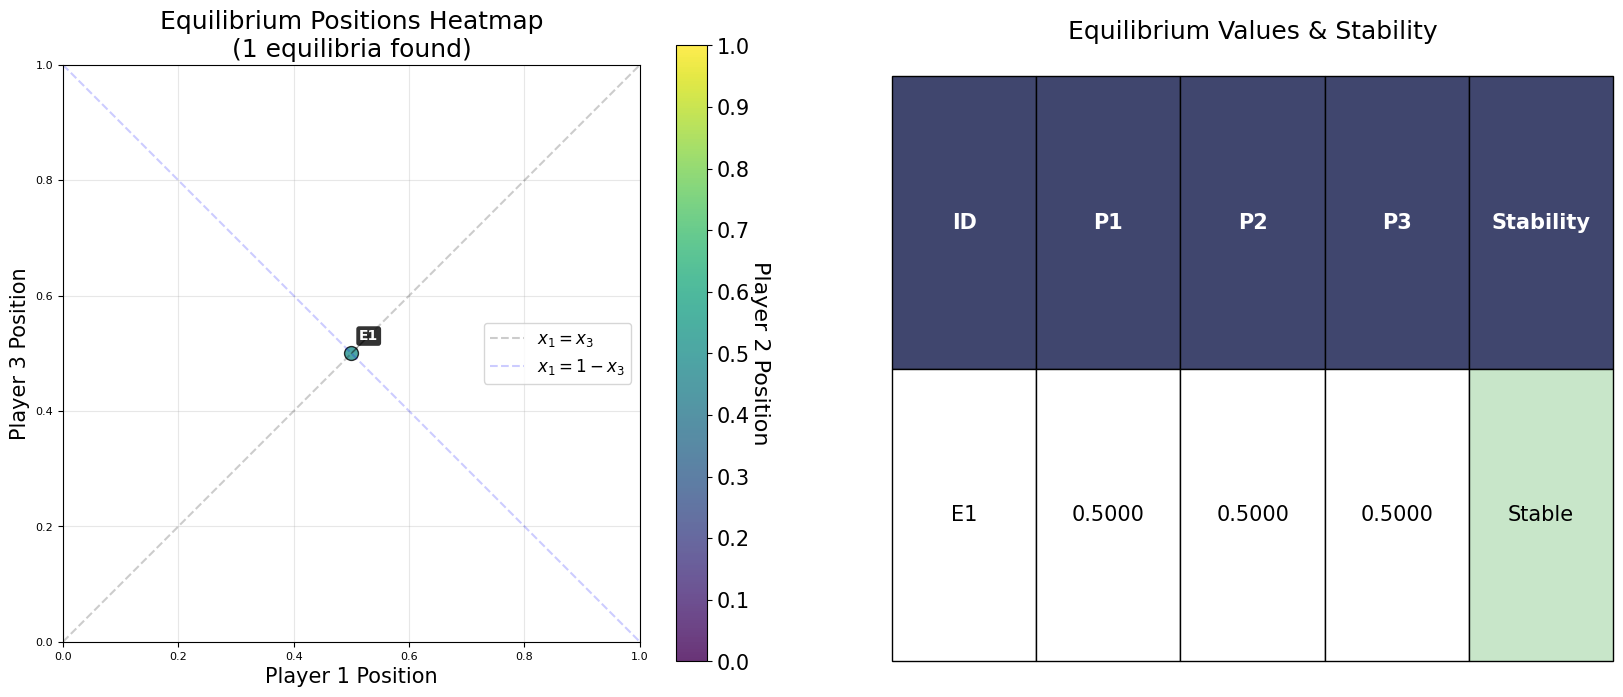

In [103]:
# Check if results and equilibria exist before plotting
if results is not None and 'unique_final_positions' in results and results['unique_final_positions'] is not None:
    if len(results['unique_final_positions']) > 0:
        plot_equilibrium_heatmap(results['unique_final_positions'], stability_analysis(vis.field,results),save=True,paper_figure={'paper':True,'section':'3_2_6','figure_id':'fig5_2'})
    else:
        print("No equilibria found to plot")
else:
    print("Error: Results is None or missing 'unique_final_positions' key")
    print(f"Results type: {type(results)}")
    if results is not None:
        print(f"Results keys: {results.keys() if isinstance(results, dict) else 'Not a dict'}")